In [1]:
import os

import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import preprocess as pp
from scLEMBAS import io

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [5]:
adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_normalized_counts.h5ad'))

# Infer TF Activity

In [6]:
n_batches = 3
batch_size = int(np.round(adata.n_obs/n_batches))
kwargs = {'args' : {'wsum' : {'times': int(1), # since we don't use the p-vals
                              'batch_size': batch_size},
                       'ulm' : {'batch_size': batch_size}, 
                        'mlm': {'batch_size': batch_size}
                       }, 
         'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['wsum_estimate', 'ulm_estimate', 'mlm_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values



adata = pp.get_tf_activity(adata = adata, 
                           organism = 'human', 
                           grn = 'collectri', 
                           verbose = True,
                           consensus = True, 
                           hvg = True,
                           static = True,
                           use_raw = False, 
                           min_n = 5, 
                           filter_pvals = False, pval_thresh = 0.05, 
                           **kwargs)

Running scores.
Running wsum on mat with 72471 samples and 5000 targets for 516 sources.


100%|█████████████████████████████████████████████| 3/3 [00:01<00:00,  2.72it/s]


Running ulm on mat with 72471 samples and 5000 targets for 516 sources.


100%|█████████████████████████████████████████████| 3/3 [00:02<00:00,  1.43it/s]


Running mlm on mat with 72471 samples and 5000 targets for 516 sources.


100%|█████████████████████████████████████████████| 3/3 [00:20<00:00,  6.67s/it]


Let's see what the data distribution looks like (and if it was transformed as in the original LEMBAS):

''

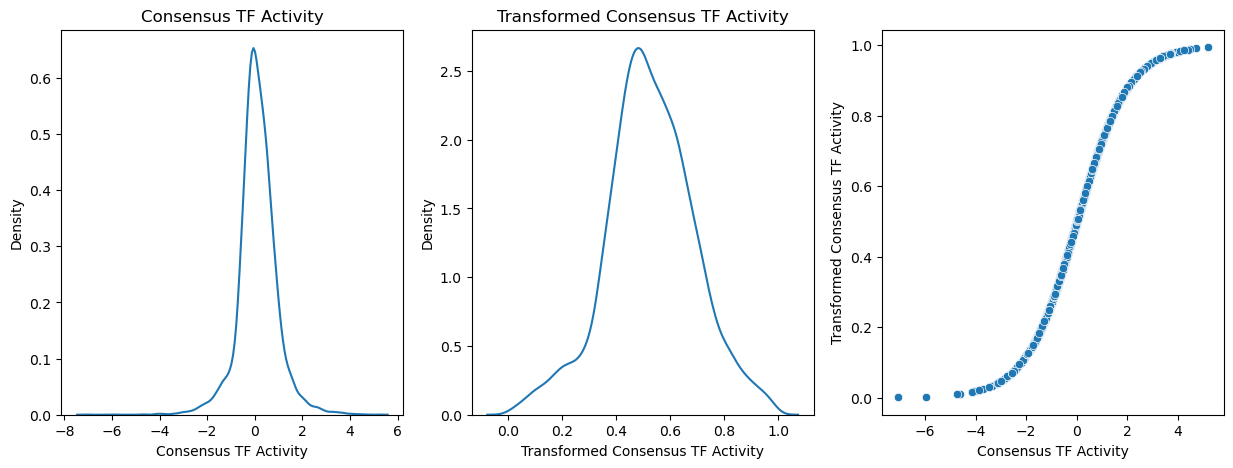

In [7]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

vals = adata.obsm['consensus_estimate'].values.flatten()
vals_transformed = pp.transform_tf_activity(adata.obsm['consensus_estimate']).values.flatten()
scores = pd.DataFrame(data = {'Consensus TF Activity': vals, 
                    'Transformed Consensus TF Activity': vals_transformed})
scores_subset = scores.sample(n=int(1e4), random_state=seed)


sns.kdeplot(scores_subset['Consensus TF Activity'], ax = ax[0])
ax[0].set_title('Consensus TF Activity')

sns.kdeplot(scores_subset['Transformed Consensus TF Activity'], ax = ax[1])
ax[1].set_title('Transformed Consensus TF Activity')

sns.scatterplot(data = scores_subset, x = 'Consensus TF Activity', 
                y = 'Transformed Consensus TF Activity', ax = ax[2])
;

In [8]:
tf_adata = pp.tf_to_adata(adata, estimate_key = 'consensus_estimate')
tf_adata = tf_adata[:, sorted(tf_adata.var_names)].copy() # doesnt change anything

Formatting

In [11]:
io.write_tfad(tf_adata, os.path.join(data_path, 'interim', author + '_tf_activity.h5ad'))